<a href="https://colab.research.google.com/github/LamaAttar/project/blob/lama/Smart_Waste_Management2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Book1.csv to Book1 (1).csv


In [ ]:
import pandas as pd

dataset = pd.read_csv("Book1 (1).csv")

dataset.head()

,Bin_ID,Location,Fill_Level,Time,Temperature
0,1,Amman,30,8:00,20
1,1,Amman,55,12:00,24
2,1,Amman,82,16:00,28
3,2,Amman,20,8:00,20
4,2,Amman,60,12:00,25


In [ ]:
dataset.columns

Index(['Bin_ID', 'Location', 'Fill_Level', 'Time', 'Temperature'], dtype='object')

First 5 rows of dataset:
   Bin_ID Location  Fill_Level   Time  Temperature
0       1    Amman          30   8:00           20
1       1    Amman          55  12:00           24
2       1    Amman          82  16:00           28
3       2    Amman          20   8:00           20
4       2    Amman          60  12:00           25

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Bin_ID       12 non-null     int64 
 1   Location     12 non-null     object
 2   Fill_Level   12 non-null     int64 
 3   Time         12 non-null     object
 4   Temperature  12 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 612.0+ bytes
None

Descriptive statistics:
          Bin_ID  Fill_Level  Temperature
count  12.000000   12.000000    12.000000
mean    2.500000   54.833333    23.333333
std     1.167748   27.554354     3.550501
min     1.00

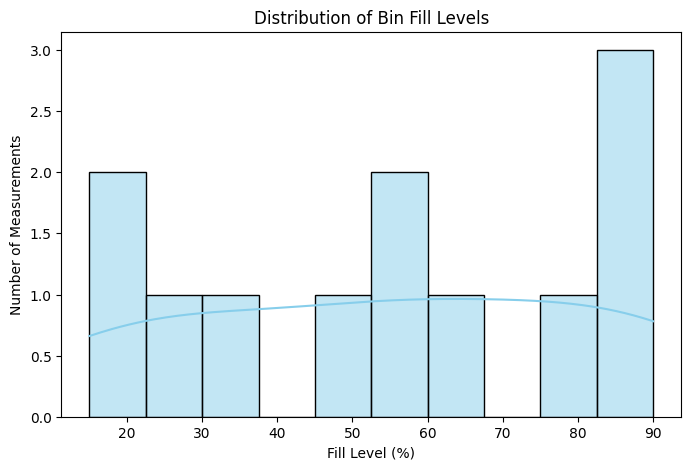

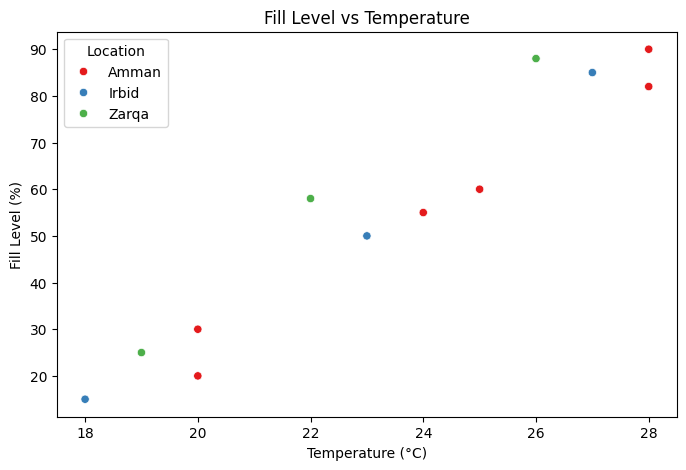

/tmp/ipykernel_1004/2477957414.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Bin_ID", y="Fill_Level", data=dataset, palette="Set2")


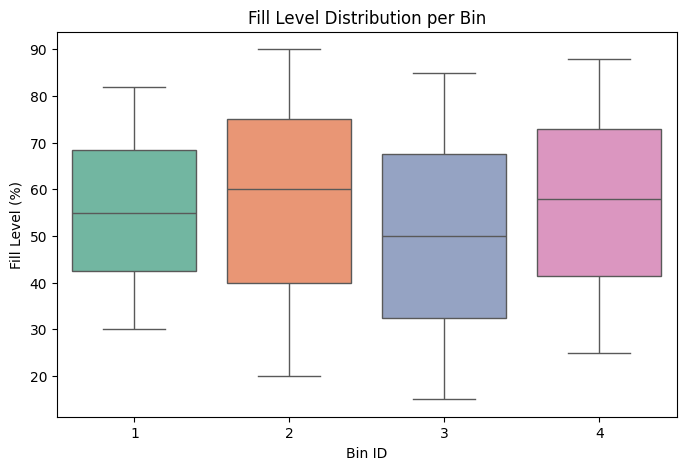


Average Fill_Level per Bin_ID:
Bin_ID
1    55.666667
2    56.666667
3    50.000000
4    57.000000
Name: Fill_Level, dtype: float64

Bins that need collection first (Fill_Level >= 80%):
[1 2 3 4]


In [ ]:
# Smart Waste Management - EDA + Visualization

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ قراءة البيانات
dataset = pd.read_csv("Book1 (1).csv")  # اسم الملف تمامًا كما ظهر بعد الرفع

# 2️⃣ عرض أول 5 صفوف
print("First 5 rows of dataset:")
print(dataset.head())

# 3️⃣ معلومات عن الأعمدة وأنواعها وعدد القيم المفقودة
print("\nDataset info:")
print(dataset.info())

# 4️⃣ إحصاءات وصفية للأعمدة الرقمية
print("\nDescriptive statistics:")
print(dataset.describe())

# 5️⃣ رسم توزيع Fill_Level
plt.figure(figsize=(8,5))
sns.histplot(dataset["Fill_Level"], bins=10, kde=True, color="skyblue")
plt.title("Distribution of Bin Fill Levels")
plt.xlabel("Fill Level (%)")
plt.ylabel("Number of Measurements")
plt.show()

# 6️⃣ Scatter Plot: Fill_Level vs Temperature
plt.figure(figsize=(8,5))
sns.scatterplot(x="Temperature", y="Fill_Level", data=dataset, hue="Location", palette="Set1")
plt.title("Fill Level vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Fill Level (%)")
plt.show()

# 7️⃣ Boxplot لكل Bin_ID
plt.figure(figsize=(8,5))
sns.boxplot(x="Bin_ID", y="Fill_Level", data=dataset, palette="Set2")
plt.title("Fill Level Distribution per Bin")
plt.xlabel("Bin ID")
plt.ylabel("Fill Level (%)")
plt.show()

# 8️⃣ حساب متوسط Fill_Level لكل Bin_ID
avg_fill = dataset.groupby("Bin_ID")["Fill_Level"].mean()
print("\nAverage Fill_Level per Bin_ID:")
print(avg_fill)

# 9️⃣ تحديد السلال التي تحتاج جمع أولًا (Fill_Level >= 80)
bins_to_collect = dataset[dataset["Fill_Level"] >= 80]["Bin_ID"].unique()
print("\nBins that need collection first (Fill_Level >= 80%):")
print(bins_to_collect)

Slope (Coefficient): 7.475961538461539
Intercept: -119.60576923076923


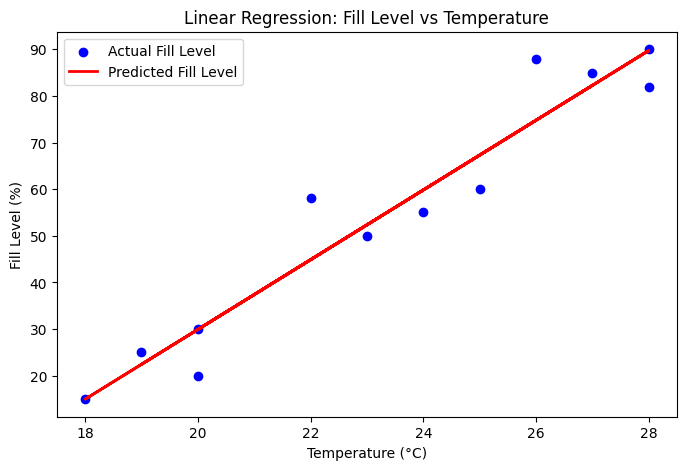


Predicted Fill Levels for new temperatures:
Temperature: 21°C → Predicted Fill Level: 37.39%
Temperature: 23°C → Predicted Fill Level: 52.34%
Temperature: 26°C → Predicted Fill Level: 74.77%
Temperature: 28°C → Predicted Fill Level: 89.72%
Temperature: 30°C → Predicted Fill Level: 104.67%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Linear Regression - Predict Fill_Level
# تولين العطار

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# 1️⃣ قراءة البيانات
dataset = pd.read_csv("Book1 (1).csv")

# 2️⃣ نختار Feature و Target
# هنا نستخدم Temperature للتنبؤ ب Fill_Level
X = dataset[["Temperature"]]  # Feature
y = dataset["Fill_Level"]     # Target

# 3️⃣ إنشاء نموذج Linear Regression
model = LinearRegression()
model.fit(X, y)

# 4️⃣ طباعة المعاملات
print(f"Slope (Coefficient): {model.coef_[0]}")
print(f"Intercept: {model.intercept_}")

# 5️⃣ التنبؤ بالقيم
y_pred = model.predict(X)

# 6️⃣ رسم البيانات الأصلية و خط التنبؤ
plt.figure(figsize=(8,5))
plt.scatter(X, y, color='blue', label='Actual Fill Level')
plt.plot(X, y_pred, color='red', linewidth=2, label='Predicted Fill Level')
plt.title("Linear Regression: Fill Level vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Fill Level (%)")
plt.legend()
plt.show()

# 7️⃣ التنبؤ بمستوى الملء عند درجات حرارة جديدة
new_temps = np.array([21, 23, 26, 28, 30]).reshape(-1,1)
predicted_fill = model.predict(new_temps)

print("\nPredicted Fill Levels for new temperatures:")
for temp, fill in zip(new_temps.flatten(), predicted_fill):
    print(f"Temperature: {temp}°C → Predicted Fill Level: {fill:.2f}%")